第1步：能量 = -0.76745289 Ha | β_0 = +0.000000
第2步：能量 = -0.76743858 Ha | β_1 = +0.013478
第3步：能量 = -0.76744616 Ha | β_2 = +0.026943
第4步：能量 = -0.76748643 Ha | β_3 = +0.040383
第5步：能量 = -0.76757012 Ha | β_4 = +0.053784
第6步：能量 = -0.76770775 Ha | β_5 = +0.067133
第7步：能量 = -0.76790965 Ha | β_6 = +0.080417
第8步：能量 = -0.76818588 Ha | β_7 = +0.093622
第9步：能量 = -0.76854623 Ha | β_8 = +0.106734
第10步：能量 = -0.76900010 Ha | β_9 = +0.119739
第11步：能量 = -0.76955654 Ha | β_10 = +0.132622
第12步：能量 = -0.77022417 Ha | β_11 = +0.145369
第13步：能量 = -0.77101112 Ha | β_12 = +0.157966
第14步：能量 = -0.77192503 Ha | β_13 = +0.170398
第15步：能量 = -0.77297299 Ha | β_14 = +0.182650
第16步：能量 = -0.77416150 Ha | β_15 = +0.194709
第17步：能量 = -0.77549644 Ha | β_16 = +0.206560
第18步：能量 = -0.77698307 Ha | β_17 = +0.218188
第19步：能量 = -0.77862595 Ha | β_18 = +0.229579
第20步：能量 = -0.78042895 Ha | β_19 = +0.240719
第21步：能量 = -0.78239523 Ha | β_20 = +0.251596
第22步：能量 = -0.78452721 Ha | β_21 = +0.262195
第23步：能量 = -0.78682657 Ha | β_22 = +0.272505
第24步：能量

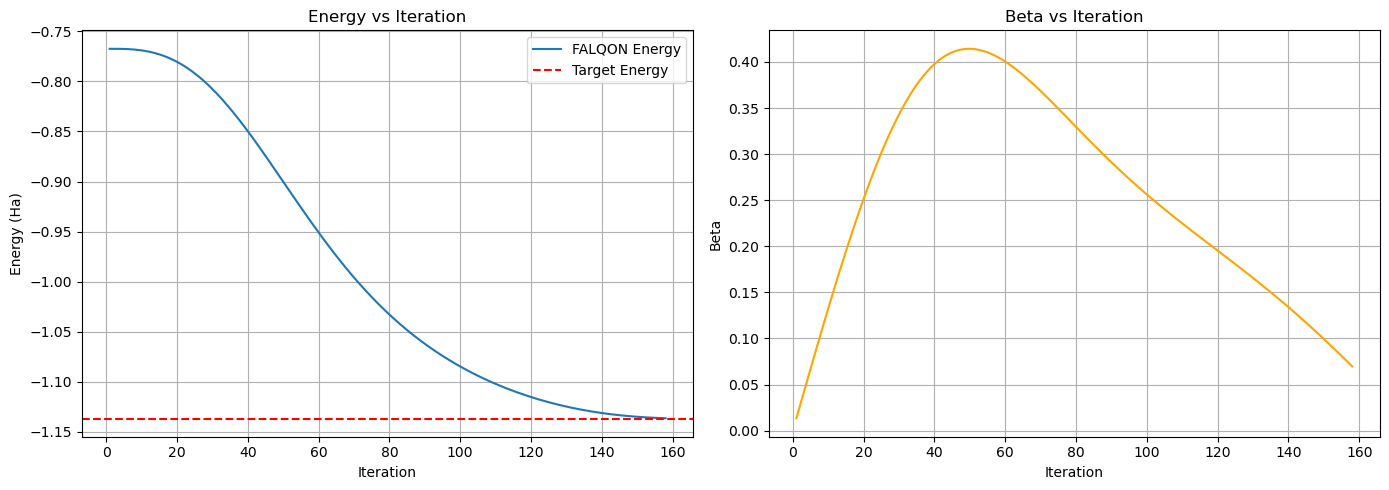

In [8]:
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.units import DistanceUnit
import numpy as np
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis.evolution import SuzukiTrotter
from qiskit import transpile
from qiskit.transpiler import CouplingMap
from qiskit.transpiler import CouplingMap
import matplotlib.pyplot as plt
import numpy as np


n_qubits = 4
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.742",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

molecule = driver.run()
mapper = JordanWignerMapper()
cost_h = mapper.map(molecule.hamiltonian.second_q_op())


driver_scaling = 0.27
driver_h = SparsePauliOp.from_list([
    ("XIII", -1.0*driver_scaling),
    ("IXII", -1.0*driver_scaling),
    ("IIXI", -1.0*driver_scaling),
    ("IIIX", -1.0*driver_scaling),
])


def build_commutator(op_a: SparsePauliOp, op_b: SparsePauliOp) -> SparsePauliOp:
    ab = op_a @ op_b
    ba = op_b @ op_a
    comm_pre= ab - ba
    comm = comm_pre*1j
    return comm.simplify()

comm_h=build_commutator(driver_h, cost_h)


def falqon_layer(qc,cost_h,driver_h,beta_k,delta_t):
    #synth = SuzukiTrotter(reps=1)   ,synthesis=synth
    U_c= PauliEvolutionGate(cost_h,delta_t)
    U_d= PauliEvolutionGate(beta_k*driver_h,delta_t)
    qc.append(U_c, range(qc.num_qubits))
    qc.append(U_d, range(qc.num_qubits))


E_set =-1.13728383

def main_loop(qc,cost_h,driver_h,comm_h,delta_t,beta_0,n_steps):
    beta =[beta_0]
    energies=[]
    state = Statevector.from_label("+" * n_qubits)
    for i in range(n_steps):
        qc_layer = QuantumCircuit(n_qubits)
        falqon_layer(qc_layer,cost_h,driver_h,beta[i],delta_t)
        qc.compose(qc_layer, inplace=True)
        state = state.evolve(qc_layer) 
        energy = state.expectation_value(cost_h).real
        energies.append(energy)
        next_beta =-1*state.expectation_value(comm_h).real
        beta.append(next_beta)
        print(f"第{i + 1}步：能量 = {energy:.8f} Ha | β_{i} = {beta[i]:+.6f}")

        if i >= 1:
            energy_diff = abs(energies[-1] - energies[-2])
            diff_to_target = abs(energies[-1] - E_set)
            #if  abs(energies[-1] - energies[-2]) < 1e-6:
            if diff_to_target < 1e-3:
                print(f" Converged at step {i + 1}!")
                print(f" Energy change ΔE = {energy_diff:.2e} Ha < 1e-6")
                print(f" different from E_set = {diff_to_target:.2e} Ha < 1e-3")
                break
        
        
    return beta, energies, qc


def uniform_superposition_circuit(n_qubits=4):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))  # 对所有 qubit 施加 H 门
    return qc

qc_initial= uniform_superposition_circuit()

n_steps = 1000
beta_0 = 0.0
delta_t = 0.03
s_beta, s_energies, final_circuit = main_loop(
    qc=qc_initial,
    cost_h=cost_h,
    driver_h=driver_h,
    comm_h=comm_h,
    delta_t=delta_t,
    beta_0=beta_0,
    n_steps=n_steps
)
print("Circuit depth:", final_circuit.depth())
# 生成迭代步列表
iterations = list(range(1, len(s_energies) + 1))
# 创建两个子图
plt.figure(figsize=(14, 5))

# 第一个子图：Energy vs Iteration
plt.subplot(1, 2, 1)
plt.plot(iterations, s_energies, label='FALQON Energy')
plt.axhline(E_set, color='red', linestyle='--', label='Target Energy')  # 添加这行
plt.title('Energy vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Energy (Ha)')
plt.legend()
plt.grid(True)

# 第二个子图：Beta vs Iteration
plt.subplot(1, 2, 2)
plt.plot(iterations, s_beta[1:], color='orange')
plt.title('Beta vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Beta')
plt.grid(True)

plt.tight_layout()
plt.show()
